# Google Playstore Case Study

In this module you’ll be learning data visualisation with the help of a case study. This will enable you to understand how visualisation aids you in solving business problems.

**Problem Statement**

The team at Google Play Store wants to develop a feature that would enable them to boost visibility for the most promising apps. Now, this analysis would require a preliminary understanding of the features that define a well-performing app. You can ask questions like:
- Does a higher size or price necessarily mean that an app would perform better than the other apps?
- Or does a higher number of installs give a clear picture of which app would have a better rating than others?




### Session 1 - Introduction to Data Visualisation

In [1]:
# Recommended versions
# numpy 	1.26.4
# pandas	2.2.2
# matplotlib	3.7.1
# seaborn	0.10.0
# plotly	5.24.1

In [1]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

Matplotlib is building the font cache; this may take a moment.


In [3]:
# read the dataset and check the first five rows
inp0 = pd.read_csv("googleplaystore_v2.csv")

In [4]:
# Check the shape of the dataframe
inp0.shape

(10841, 13)

In [5]:
inp0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  float64
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), object(11)
memory usage: 1.1+ MB


In [6]:
app = inp0.loc[inp0["Rating"] == 19.0]

In [7]:
inp1 = inp0[~inp0["Rating"].isnull()]

In [8]:
inp1

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.000000,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.000000,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.000000,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.000000,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.000000,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10834,FR Calculator,FAMILY,4.0,7,2600.000000,500+,Free,0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.000000,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.000000,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,21516.529524,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [9]:
inp1[inp1["Android Ver"].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.000000,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.000000,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,21516.529524,Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


### We don't want to hardcode a particular row, instead better approach is by conditioning, for example if we did not have an index

In [10]:
# inp1.drop(10472,inplace=True) Bad strategy

## Batter Approach through conditions

In [11]:
cond = (inp1["Android Ver"].isnull()) & (inp1["Rating"] == 19.0)

In [12]:
inp1 = inp1[~cond]

In [13]:
inp1[inp1["Android Ver"].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.0,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.0,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


In [14]:
inp1[inp1["Android Ver"].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230,11000.0,"1,000+",Paid,$1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189,2100.0,"10,000+",Free,0,Everyone,Personalization,"March 27, 2018",1.1,NaN


In [15]:
inp1["Android Ver"].value_counts()

Android Ver
4.1 and up            2059
Varies with device    1319
4.0.3 and up          1240
4.0 and up            1131
4.4 and up             875
2.3 and up             582
5.0 and up             535
4.2 and up             338
2.3.3 and up           240
3.0 and up             211
2.2 and up             208
4.3 and up             207
2.1 and up             113
1.6 and up              87
6.0 and up              48
7.0 and up              41
3.2 and up              31
2.0 and up              27
5.1 and up              18
1.5 and up              16
3.1 and up               8
2.0.1 and up             7
4.4W and up              6
8.0 and up               5
7.1 and up               3
4.0.3 - 7.1.1            2
5.0 - 8.0                2
1.0 and up               2
7.0 - 7.1.1              1
4.1 - 7.1.1              1
5.0 - 6.0                1
Name: count, dtype: int64

Replace missing values with most commonly occuring value
### Don't hardcode...bad strategy


In [16]:
# inp1['Android Ver'].fillna('4.1 and up',inplace=True) #

In [17]:
common = inp1["Android Ver"].mode()[0]

In [18]:
inp1["Android Ver"] = inp1["Android Ver"].fillna(common)

/var/folders/lj/nxvzwr3x3b9bfrgtmp4tfjjw0000gn/T/ipykernel_5195/3221511036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inp1["Android Ver"] = inp1["Android Ver"].fillna(common)


In [19]:
inp1.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       4
Android Ver       0
dtype: int64

In [20]:
inp1[inp1["Current Ver"].isnull()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55,2700.0,"5,000+",Free,0,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145,11.0,"1,000,000+",Free,0,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010,8700.0,"500,000+",Free,0,Everyone,Tools,"May 10, 2017",NaN,4.0 and up
7333,Dots puzzle,FAMILY,4.0,179,14000.0,"50,000+",Paid,$0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up


In [21]:
inp1["Current Ver"].value_counts()

Current Ver
Varies with device    1415
1.0                    458
1.1                    195
1.2                    126
1.3                    120
                      ... 
2.9.10                   1
3.18.5                   1
1.3.A.2.9                1
9.9.1.1910               1
0.3.4                    1
Name: count, Length: 2638, dtype: int64

In [22]:
common_ver = inp1["Current Ver"].mode()[0]

In [23]:
inp1["Current Ver"] = inp1["Current Ver"].fillna(common_ver)

/var/folders/lj/nxvzwr3x3b9bfrgtmp4tfjjw0000gn/T/ipykernel_5195/2577739145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inp1["Current Ver"] = inp1["Current Ver"].fillna(common_ver)


In the case of the Android Ver column, you imputed, or you replaced the missing value with the mode for that column. Computing the mode can be done either using the value_counts() function or using the mode function directly.

Imputations are generally done when keeping the missing values disbars you from doing further analysis and eliminating the rows containing those values leads to some bias. The estimation is based on the mean, mode, median, etc. of the data.

In cases where there are numerical columns involved, both mean and median offer up as a good imputed value. In the case of the categorical column, mode turns out to be a decent enough imputation to carry out.

In [24]:
inp1.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [25]:
inp1["Current Ver"].value_counts()

Current Ver
Varies with device    1419
1.0                    458
1.1                    195
1.2                    126
1.3                    120
                      ... 
2.9.10                   1
3.18.5                   1
1.3.A.2.9                1
9.9.1.1910               1
0.3.4                    1
Name: count, Length: 2638, dtype: int64

### Data Handling and Cleaning

The first few steps involve making sure that there are no __missing values__ or __incorrect data types__ before we proceed to the analysis stage. These aforementioned problems are handled as follows:

 - For Missing Values: Some common techniques to treat this issue are
    - Dropping the rows containing the missing values
    - Imputing the missing values
    - Keep the missing values if they don't affect the analysis

    
 - Incorrect Data Types:
    - Clean certain values
    - Clean and convert an entire column


In [26]:
# Check the datatypes of all the columns of the dataframe

#### Missing Value Treatment

In [27]:
# Check the number of null values in the columns

Handling missing values for rating
 - Ratings is the target variable
 - drop the records

In [28]:
# Drop the rows having null values in the Rating field


# Check the shape of the dataframe

In [29]:
# Check the number of nulls in the Rating field again to cross-verify

In [30]:
# Question
# Check the number of nulls in the dataframe again and find the total number of null values

In [31]:
# Inspect the nulls in the Android Version column

In [32]:
# Drop the row having shifted values

# Check the nulls againin Android version column to cross-verify

Imputing Missing Values

- For numerical variables use mean and median
- For categorical variables use mode

In [33]:
# Check the most common value in the Android version column

In [34]:
# Fill up the nulls in the Android Version column with the above value

In [35]:
# Check the nulls in the Android version column again to cross-verify

In [36]:
# Check the nulls in the entire dataframe again

In [37]:
# Check the most common value in the Current version column

In [38]:
# Replace the nulls in the Current version column with the above value

In [39]:
# Question : Check the most common value in the Current version column again

#### Handling Incorrect Data Types

In [40]:
# Check the datatypes of all the columns

In [41]:
# Question - Try calculating the average price of all apps having the Android version as "4.1 and up"

In [42]:
# Analyse the Price column to check the issue
inp1.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size              float64
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [43]:
# Write the function to make the changes
inp1[inp1["Type"] == "Paid"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6800.000000,"100,000+",Paid,$4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39000.000000,"100,000+",Paid,$4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
290,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6800.000000,"100,000+",Paid,$4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39000.000000,"100,000+",Paid,$4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,21516.529524,"100,000+",Paid,$3.99,Everyone,Communication,"July 5, 2018",7.5.3.20547,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10690,FO Bixby,PERSONALIZATION,5.0,5,861.000000,100+,Paid,$0.99,Everyone,Personalization,"April 25, 2018",0.2,7.0 and up
10697,Mu.F.O.,GAME,5.0,2,16000.000000,1+,Paid,$0.99,Everyone,Arcade,"March 3, 2017",1.0,2.3 and up
10760,Fast Tract Diet,HEALTH_AND_FITNESS,4.4,35,2400.000000,"1,000+",Paid,$7.99,Everyone,Health & Fitness,"August 8, 2018",1.9.3,4.2 and up
10782,Trine 2: Complete Story,GAME,3.8,252,11000.000000,"10,000+",Paid,$16.99,Teen,Action,"February 27, 2015",2.22,5.0 and up


In [44]:
def clean_price(val):
    if val == "0":
        return float(0)
    elif val[0] == "$":
        return float(val[1:])

In [45]:
inp1["Price"] = inp1["Price"].apply(clean_price)

/var/folders/lj/nxvzwr3x3b9bfrgtmp4tfjjw0000gn/T/ipykernel_5195/3654723066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inp1["Price"] = inp1["Price"].apply(clean_price)


In [46]:
inp1["Price"].dtype

dtype('float64')

In [47]:
inp1[inp1["Android Ver"] == common]["Price"].mean()

np.float64(0.8191606016496848)

In [48]:
# Verify the dtype of Price once again

In [49]:
# Analyse the Reviews column
inp1["Reviews"].max()

'9992'

In [50]:
def clean_reviews(val):
    return int(val)

In [51]:
inp1["Reviews"] = inp1["Reviews"].astype("int32")

/var/folders/lj/nxvzwr3x3b9bfrgtmp4tfjjw0000gn/T/ipykernel_5195/2536926778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inp1["Reviews"] = inp1["Reviews"].astype("int32")


In [52]:
inp1.dtypes

App                object
Category           object
Rating            float64
Reviews             int32
Size              float64
Installs           object
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [53]:
# Change the dtype of this column


# Check the quantitative spread of this dataframe

In [54]:
inp1.Reviews.describe()

count    9.366000e+03
mean     5.140498e+05
std      3.144042e+06
min      1.000000e+00
25%      1.862500e+02
50%      5.930500e+03
75%      8.153275e+04
max      7.815831e+07
Name: Reviews, dtype: float64

### Cleaning the installs column

In [55]:
inp1.Installs.head()

0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
Name: Installs, dtype: object

In [56]:
def clean_installs(val):
    out = "0"
    for el in val:
        if "0" <= el <= "9":
            out += el
    return int(out)

In [57]:
inp1["Installs"] = inp1["Installs"].apply(clean_installs)

/var/folders/lj/nxvzwr3x3b9bfrgtmp4tfjjw0000gn/T/ipykernel_5195/3407005595.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inp1["Installs"] = inp1["Installs"].apply(clean_installs)


In [58]:
# Analyse the Installs Column
inp1.Installs.describe()

count    9.366000e+03
mean     1.789744e+07
std      9.123822e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

In [59]:
# Question Clean the Installs Column and find the approximate number of apps at the 50th percentile.

#### Sanity Checks

The data that we have needs to make sense and therefore you can perform certain sanity checks on them to ensure they are factually correct as well. Some sanity checks can be:

- Rating is between 1 and 5 for all the apps.
- Number of Reviews is less than or equal to the number of Installs.
- Free Apps shouldn’t have a price greater than 0.


In [60]:
# Perform the sanity checks on the Reviews column
(inp1["Rating"] <= 5).all()

np.True_

In [61]:
inp1[inp1["Reviews"] > inp1["Installs"]]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2454,KBA-EZ Health Guide,MEDICAL,5.0,4,25000.000000,1,Free,0.00,Everyone,Medical,"August 2, 2018",1.0.72,4.0.3 and up
4663,Alarmy (Sleep If U Can) - Pro,LIFESTYLE,4.8,10249,21516.529524,10000,Paid,2.49,Everyone,Lifestyle,"July 30, 2018",Varies with device,Varies with device
5917,Ra Ga Ba,GAME,5.0,2,20000.000000,1,Paid,1.49,Everyone,Arcade,"February 8, 2017",1.0.4,2.3 and up
6700,Brick Breaker BR,GAME,5.0,7,19000.000000,5,Free,0.00,Everyone,Arcade,"July 23, 2018",1.0,4.1 and up
7402,Trovami se ci riesci,GAME,5.0,11,6100.000000,10,Free,0.00,Everyone,Arcade,"March 11, 2017",0.1,2.3 and up
8591,DN Blog,SOCIAL,5.0,20,4200.000000,10,Free,0.00,Teen,Social,"July 23, 2018",1.0,4.0 and up
10697,Mu.F.O.,GAME,5.0,2,16000.000000,1,Paid,0.99,Everyone,Arcade,"March 3, 2017",1.0,2.3 and up


### Above records will mess up our analysis of the dataset, we will drop these records

In [62]:
inp1 = inp1[inp1["Reviews"] <= inp1["Installs"]]

In [63]:
inp1[inp1["Reviews"] > inp1["Installs"]]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [64]:
(inp1["Rating"] >= 1).all()

np.True_

In [65]:
# perform the sanity checks on prices of free
inp1[(inp1["Type"] == "Free") & (inp1["Price"] > 0)].shape

(0, 13)

#### Outliers Analysis Using Boxplot

Now you need to start identifying and removing extreme values or __outliers__ from our dataset. These values can tilt our analysis and often provide us with a biased perspective of the data available. This is where you’ll start utilising visualisation to achieve your tasks. And the best visualisation to use here would be the box plot. Boxplots are one of the best ways of analysing the spread of a numeric variable


Using a box plot you can identify the outliers as follows:

![BoxPlots to Identify Outliers](images/Boxplot.png)

- Outliers in data can arise due to genuine reasons or because of dubious entries. In the latter case, you should go ahead and remove such entries immediately. Use a boxplot to observe, analyse and remove them.
- In the former case, you should determine whether or not removing them would add value to your analysis procedure.

- You can create a box plot directly from pandas dataframe or the matplotlib way as you learnt in the previous session. Check out their official documentation here:
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html
   - https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.boxplot.html

In [66]:
# import the plotting libraries
inp1["Price"].value_counts()

Price
0.00      8715
2.99       114
0.99       106
4.99        70
1.99        59
          ... 
1.29         1
299.99       1
379.99       1
37.99        1
1.20         1
Name: count, Length: 73, dtype: int64

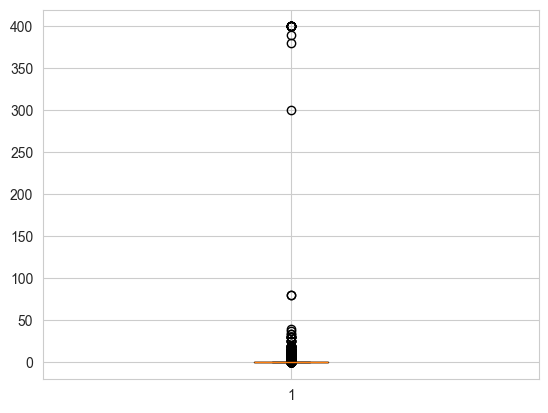

In [67]:
# Create a box plot for the price column
plt.boxplot(inp1["Price"])
plt.show()

In [68]:
# Check the apps with price more than 200
inp1[inp1["Price"] > 200]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4197,most expensive app (H),FAMILY,4.3,6,1500.0,100,Paid,399.99,Everyone,Entertainment,"July 16, 2018",1.0,7.0 and up
4362,💎 I'm rich,LIFESTYLE,3.8,718,26000.0,10000,Paid,399.99,Everyone,Lifestyle,"March 11, 2018",1.0.0,4.4 and up
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7300.0,10000,Paid,400.00,Everyone,Lifestyle,"May 3, 2018",1.0.1,4.1 and up
5351,I am rich,LIFESTYLE,3.8,3547,1800.0,100000,Paid,399.99,Everyone,Lifestyle,"January 12, 2018",2.0,4.0.3 and up
5354,I am Rich Plus,FAMILY,4.0,856,8700.0,10000,Paid,399.99,Everyone,Entertainment,"May 19, 2018",3.0,4.4 and up
5355,I am rich VIP,LIFESTYLE,3.8,411,2600.0,10000,Paid,299.99,Everyone,Lifestyle,"July 21, 2018",1.1.1,4.3 and up
5356,I Am Rich Premium,FINANCE,4.1,1867,4700.0,50000,Paid,399.99,Everyone,Finance,"November 12, 2017",1.6,4.0 and up
5357,I am extremely Rich,LIFESTYLE,2.9,41,2900.0,1000,Paid,379.99,Everyone,Lifestyle,"July 1, 2018",1.0,4.0 and up
5358,I am Rich!,FINANCE,3.8,93,22000.0,1000,Paid,399.99,Everyone,Finance,"December 11, 2017",1.0,4.1 and up
5359,I am rich(premium),FINANCE,3.5,472,965.0,5000,Paid,399.99,Everyone,Finance,"May 1, 2017",3.4,4.4 and up


In [69]:
# Clean the Price column
inp1 = inp1[inp1["Price"] <= 200]

{'whiskers': [<matplotlib.lines.Line2D at 0x114fd64e0>,
 'caps': [<matplotlib.lines.Line2D at 0x114fd6c30>,
 'boxes': [<matplotlib.lines.Line2D at 0x114fd5d90>],
 'medians': [<matplotlib.lines.Line2D at 0x114fd7320>],
 'fliers': [<matplotlib.lines.Line2D at 0x114fd76e0>],
 'means': []}

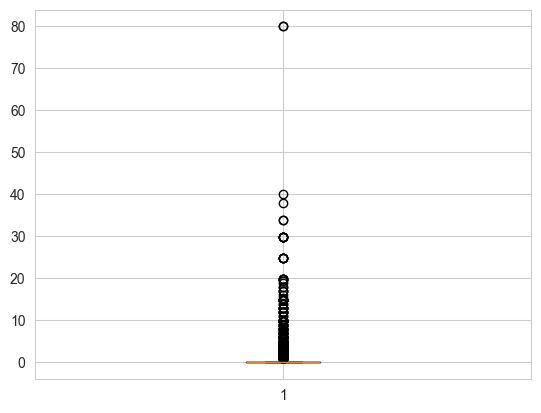

In [70]:
plt.boxplot(inp1["Price"])

In [71]:
inp1["Price"].describe()

count    9344.000000
mean        0.334463
std         2.169925
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        79.990000
Name: Price, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x11581d610>,
 'caps': [<matplotlib.lines.Line2D at 0x11581dca0>,
 'boxes': [<matplotlib.lines.Line2D at 0x11581d310>],
 'medians': [<matplotlib.lines.Line2D at 0x11581e2a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x11581e5d0>],
 'means': []}

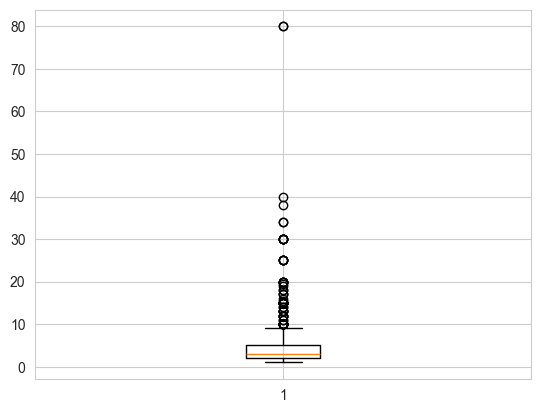

In [72]:
plt.boxplot(inp1[inp1["Price"] > 0].Price)

<Axes: >

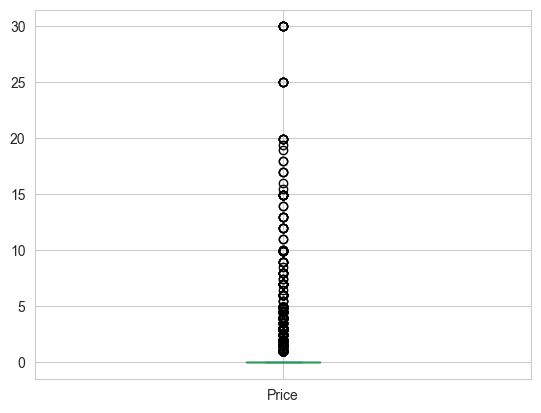

In [73]:
# Create a box plot for paid apps
inp1[(inp1["Price"] < 30)]["Price"].plot.box()

In [74]:
# Check the apps with price more than 30
inp1[inp1.Price > 30]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2253,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32000.0,1000,Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up
2301,A Manual of Acupuncture,MEDICAL,3.5,214,68000.0,1000,Paid,33.99,Everyone,Medical,"October 2, 2017",2.1.35,4.0 and up
2365,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32000.0,1000,Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up
2402,A Manual of Acupuncture,MEDICAL,3.5,214,68000.0,1000,Paid,33.99,Everyone,Medical,"October 2, 2017",2.1.35,4.0 and up
2414,LTC AS Legal,MEDICAL,4.0,6,1300.0,100,Paid,39.99,Everyone,Medical,"April 4, 2018",3.0.1,4.1 and up
5360,I am Rich Person,LIFESTYLE,4.2,134,1800.0,1000,Paid,37.99,Everyone,Lifestyle,"July 18, 2017",1.0,4.0.3 and up


In [75]:
# Clean the Price column again

In [76]:
inp1 = inp1[inp1.Price <= 30]

<Axes: >

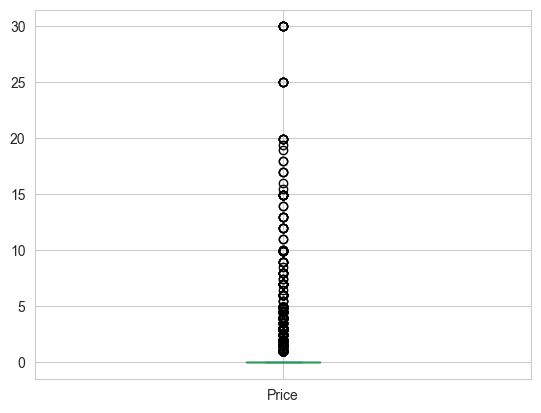

In [77]:
inp1.Price.plot.box()

In [78]:
inp1.shape

(9338, 13)

In [79]:
inp1[inp1.Price > 20].shape

(11, 13)

In [80]:
inp1[inp1.Price > 20]  # Still fishy...

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2251,Human Anatomy Atlas 2018: Complete 3D Human Body,MEDICAL,4.5,2921,25000.0,100000,Paid,24.99,Everyone,Medical,"May 25, 2018",2018.5.47,5.0 and up
2266,EMT PASS,MEDICAL,3.4,51,2400.0,1000,Paid,29.99,Everyone,Medical,"October 22, 2014",2.0.2,4.0 and up
2277,"Muscle Premium - Human Anatomy, Kinesiology, B...",MEDICAL,4.2,168,25000.0,10000,Paid,24.99,Everyone,Medical,"August 11, 2017",7.1.17,4.4 and up
2298,PTA Content Master,MEDICAL,4.2,64,41000.0,1000,Paid,29.99,Everyone,Medical,"December 22, 2015",2.1,2.2 and up
2372,Human Anatomy Atlas 2018: Complete 3D Human Body,MEDICAL,4.5,2921,25000.0,100000,Paid,24.99,Everyone,Medical,"May 25, 2018",2018.5.47,5.0 and up
2387,EMT PASS,MEDICAL,3.4,51,2400.0,1000,Paid,29.99,Everyone,Medical,"October 22, 2014",2.0.2,4.0 and up
2406,PTA Content Master,MEDICAL,4.2,64,41000.0,1000,Paid,29.99,Everyone,Medical,"December 22, 2015",2.1,2.2 and up
2407,"Muscle Premium - Human Anatomy, Kinesiology, B...",MEDICAL,4.2,168,25000.0,10000,Paid,24.99,Everyone,Medical,"August 11, 2017",7.1.17,4.4 and up
3039,Golfshot Plus: Golf GPS,SPORTS,4.1,3387,25000.0,50000,Paid,29.99,Everyone,Sports,"July 11, 2018",4.18.0,4.1 and up
5489,AP Art History Flashcards,FAMILY,5.0,1,96000.0,10,Paid,29.99,Mature 17+,Education,"January 19, 2016",3.30,4.0 and up


### Histograms

Histograms can also be used in conjuction with boxplots for data cleaning and data handling purposes. You can use it to check the spread of a numeric variable. Histograms generally work by bucketing the entire range of values that a particular variable takes to specific __bins__. After that, it uses vertical bars to denote the total number of records in a specific bin, which is also known as its __frequency__.


In a histogram, "bins" or "intervals" are the ranges of values used to group data, and each bin is represented by a bar whose height indicates the frequency of data points within that range.

![Histogram](images/Histogram.png)

You can adjust the number of bins to improve its granularity

![Bins change](images/Granular.png)

You'll be using plt.hist() to plot a histogram. Check out its official documentation: [Matplotlib Histogram Documentation](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hist.html)

In [81]:
np.histogram([1, 2, 1], bins=[0, 1, 2, 3])

(array([0, 2, 1]), array([0, 1, 2, 3]))

[ 1.3315865   0.71527897 -1.54540029 ...  5.74446677  6.22449239
  8.42055014] 2.481630150740717 10.586331523462286 2000


Text(0.5, 1.0, "Histogram with 'auto' bins")

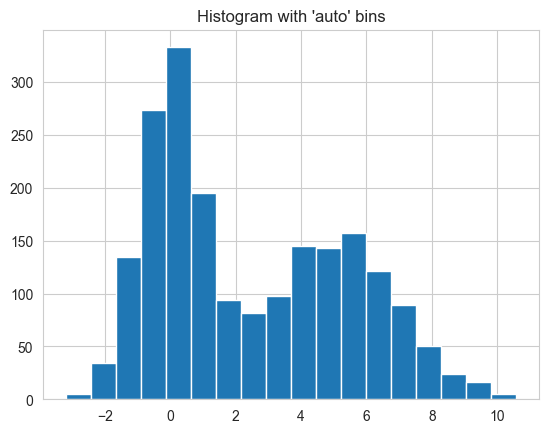

In [82]:
rng = np.random.RandomState(10)  # deterministic random data
a = np.hstack((rng.normal(size=1000), rng.normal(loc=5, scale=2, size=1000)))
print(a, np.mean(a), a.max(), len(a))
plt.hist(a, bins="auto")  # arguments are passed to np.histogram
plt.title("Histogram with 'auto' bins")

In [83]:
rng.normal(size=3, loc=2, scale=2)

array([-0.58981714,  3.35187007,  1.87233318])

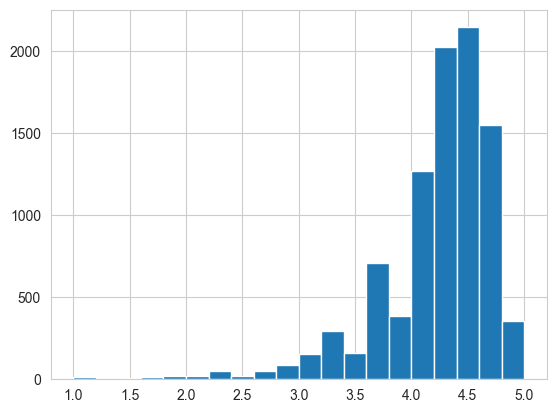

In [84]:
plt.hist(inp1["Rating"], bins=20)
plt.show()

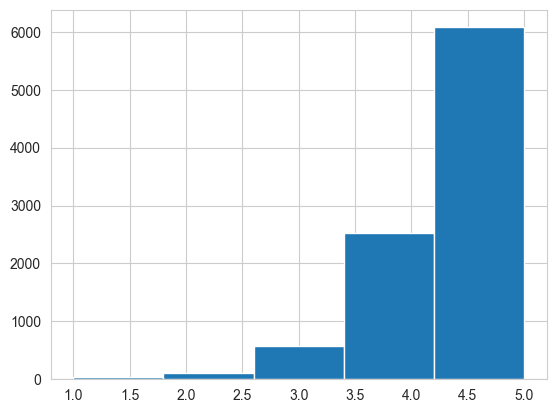

In [85]:
plt.hist(inp1["Rating"], bins=5)
plt.show()

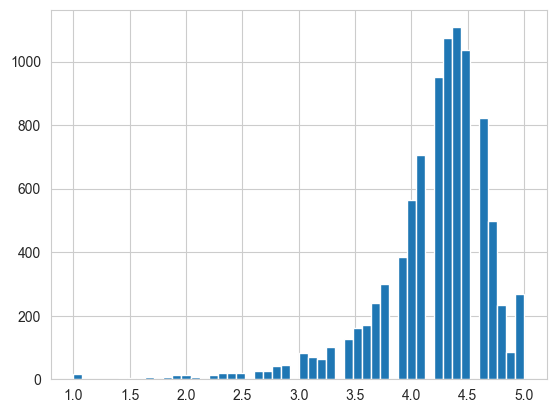

In [86]:
plt.hist(inp1["Rating"], bins=50)
plt.show()

In [87]:
inp1[inp1["Rating"] >= 4.3].shape

(5128, 13)

In [88]:
sweet = inp1[
    (inp1["Rating"] >= 4.0) & (inp1["Rating"] <= 4.6) & (inp1["Type"] == "Paid")
].shape
sweet

(389, 13)

In [89]:
sweet[0] / (inp1.shape[0])

0.04165774255729278

In [90]:
inp1[(inp1["Rating"] >= 4) & (inp1["Rating"] <= 4.6)].shape

(6263, 13)

count    9.338000e+03
mean     5.155891e+05
std      3.148627e+06
min      1.000000e+00
25%      1.890000e+02
50%      6.011500e+03
75%      8.247100e+04
max      7.815831e+07
Name: Reviews, dtype: float64


(array([8.833e+03, 1.650e+02, 8.900e+01, 8.700e+01, 3.800e+01, 2.300e+01,
        3.300e+01, 1.000e+01, 5.000e+00, 1.000e+01, 5.000e+00, 3.000e+00,
        0.000e+00, 0.000e+00, 1.100e+01, 1.000e+00, 2.000e+00, 6.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 4.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        4.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([1.00000000e+00, 1.56316710e+06, 3.12633320e+06, 4.68949930e+06,
        6.25266540e+06, 7.81583150e+06, 9.37899760e+06, 1.09421637e+07,
        1.25053298e+07, 1.40684959e+07, 1.56316620e+07, 1.71948281e+07,
        1.87579942e+07, 2.03211603e+07, 2.18843264e+07, 2.34474925e+07,
        2.50106586e+07, 2.65738247e+07, 2.81369908e+07, 2.97001569e+07,
        3.126332

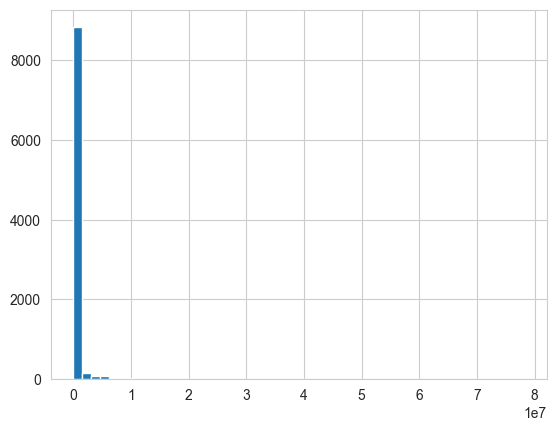

In [91]:
# Create a histogram of the Reviews
print(inp1["Reviews"].describe())
# inp1.Reviews.plot.hist(bins='auto')
plt.hist(inp1["Reviews"], bins=50)

In [92]:
(inp1["Reviews"].describe())

count    9.338000e+03
mean     5.155891e+05
std      3.148627e+06
min      1.000000e+00
25%      1.890000e+02
50%      6.011500e+03
75%      8.247100e+04
max      7.815831e+07
Name: Reviews, dtype: float64

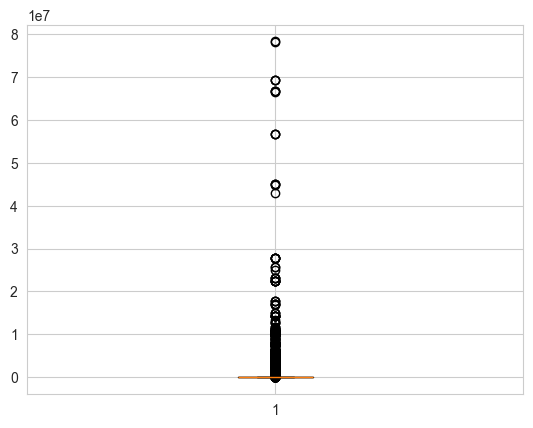

In [93]:
# Create a boxplot of the Reviews column
plt.boxplot(
    inp1["Reviews"],
)
plt.show()

(array([247., 172., 142., 123., 116.,  67.,  54.,  72.,  65.,  51.,  51.,
         51.,  44.,  48.,  40.,  38.,  40.,  30.,  36.,  35.]),
 array([101. , 145.9, 190.8, 235.7, 280.6, 325.5, 370.4, 415.3, 460.2,
        505.1, 550. , 594.9, 639.8, 684.7, 729.6, 774.5, 819.4, 864.3,
        909.2, 954.1, 999. ]),
 <BarContainer object of 20 artists>)

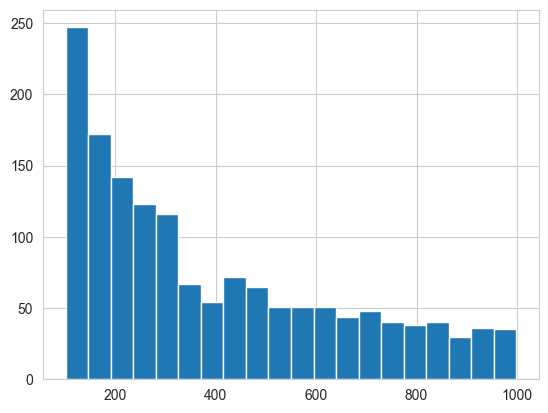

In [94]:
plt.hist(inp1[(inp1.Reviews > 100) & (inp1["Reviews"] < 1000)].Reviews, bins=20)

(array([9.045e+03, 1.670e+02, 6.600e+01, 1.500e+01, 8.000e+00, 1.100e+01,
        3.000e+00, 6.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 4.000e+00,
        0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 7.000e+00,
        0.000e+00, 2.000e+00]),
 array([1.00000000e+00, 3.90791625e+06, 7.81583150e+06, 1.17237468e+07,
        1.56316620e+07, 1.95395772e+07, 2.34474925e+07, 2.73554078e+07,
        3.12633230e+07, 3.51712382e+07, 3.90791535e+07, 4.29870688e+07,
        4.68949840e+07, 5.08028992e+07, 5.47108145e+07, 5.86187298e+07,
        6.25266450e+07, 6.64345602e+07, 7.03424755e+07, 7.42503908e+07,
        7.81583060e+07]),
 <BarContainer object of 20 artists>)

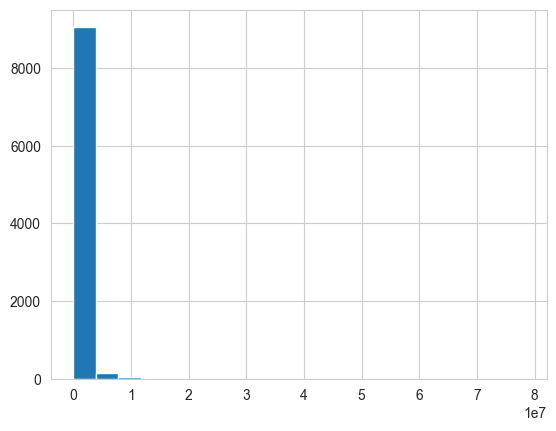

In [95]:
plt.hist(inp1.Reviews, bins=20)

In [96]:
# Check records with 1 million
inp1[inp1["Reviews"] >= 10000000]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
335,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56642847,21516.529524,1000000000,Free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,21516.529524,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
342,Viber Messenger,COMMUNICATION,4.3,11334799,21516.529524,500000000,Free,0.0,Everyone,Communication,"July 18, 2018",Varies with device,Varies with device
378,UC Browser - Fast Download Private & Secure,COMMUNICATION,4.5,17712922,40000.000000,500000000,Free,0.0,Teen,Communication,"August 2, 2018",12.8.5.1121,4.0 and up
381,WhatsApp Messenger,COMMUNICATION,4.4,69119316,21516.529524,1000000000,Free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6449,BBM - Free Calls & Messages,COMMUNICATION,4.3,12843436,21516.529524,100000000,Free,0.0,Everyone,Communication,"August 2, 2018",Varies with device,4.0.3 and up
7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,24900999,21516.529524,500000000,Free,0.0,Everyone,Tools,"August 4, 2018",4.6.6,Varies with device
7937,Shadow Fight 2,GAME,4.6,10981850,88000.000000,100000000,Free,0.0,Everyone 10+,Action,"July 2, 2018",1.9.38,3.0 and up
8894,Cache Cleaner-DU Speed Booster (booster & clea...,TOOLS,4.5,12759815,15000.000000,100000000,Free,0.0,Everyone,Tools,"July 25, 2018",3.1.2,4.0 and up


In [97]:
# Drop the above records
inp1 = inp1[inp1.Reviews <= 1000000]
inp1.shape

(8634, 13)

In [98]:
9246 - 69

9177

In [99]:
inp1 = inp1[inp1.Installs < 100000000]

In [100]:
(inp1["Installs"].mode()[0],)  # 1,000,000

(np.int64(1000000),)

In [101]:
inp1["Reviews"].describe()

count      8573.000000
mean      64815.897469
std      148951.853211
min           1.000000
25%         141.000000
50%        3484.000000
75%       43677.000000
max      995002.000000
Name: Reviews, dtype: float64

<Axes: ylabel='Frequency'>

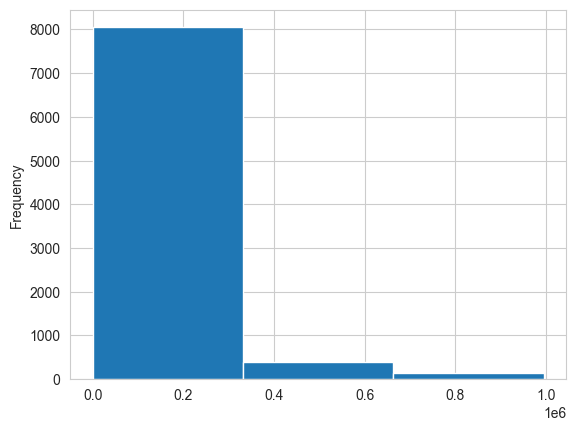

In [102]:
# Question - Create a histogram again and check the peaks
inp1["Reviews"].plot.hist(bins=3)

{'whiskers': [<matplotlib.lines.Line2D at 0x115e2d1f0>,
 'caps': [<matplotlib.lines.Line2D at 0x115e2d640>,
 'boxes': [<matplotlib.lines.Line2D at 0x115c3fd40>],
 'medians': [<matplotlib.lines.Line2D at 0x115e2dc40>],
 'fliers': [<matplotlib.lines.Line2D at 0x115e2deb0>],
 'means': []}

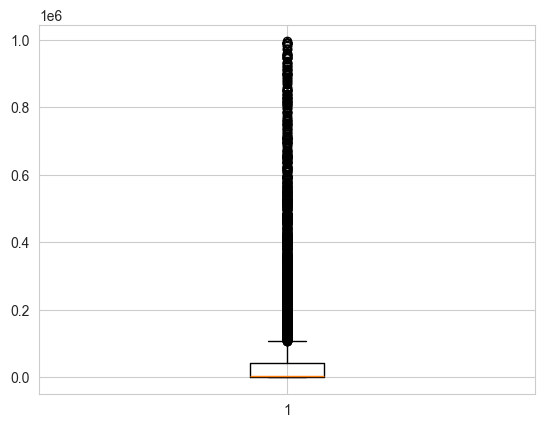

In [103]:
plt.boxplot(inp1.Reviews)

In [104]:
inp1[inp1.Installs > 100000000].count()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

{'whiskers': [<matplotlib.lines.Line2D at 0x115e2e930>,
 'caps': [<matplotlib.lines.Line2D at 0x115e2f7d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x115e1d430>],
 'medians': [<matplotlib.lines.Line2D at 0x115eac560>],
 'fliers': [<matplotlib.lines.Line2D at 0x115eac890>],
 'means': []}

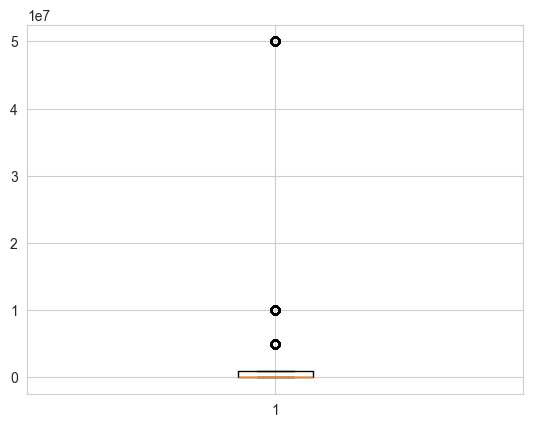

In [105]:
# Question - Create a box plot for the Installs column and report back the IQR
plt.boxplot(inp1.Installs)

In [106]:
# Question - CLean the Installs by removing all the apps having more than or equal to 100 million installs

In [107]:
print(inp1.Installs.describe())
print(np.percentile(inp1.Installs, q=75) - np.percentile(inp1.Installs, q=25))
990000 == 9.9 * (10**5)

count    8.573000e+03
mean     2.849320e+06
std      6.946426e+06
min      5.000000e+00
25%      1.000000e+04
50%      1.000000e+05
75%      1.000000e+06
max      5.000000e+07
Name: Installs, dtype: float64
990000.0


True

(array([3216., 1348., 2190.,  562.,  422.,  269.,  177.,  126.,  106.,
         157.]),
 array([8.500000e+00, 1.000765e+04, 2.000680e+04, 3.000595e+04,
        4.000510e+04, 5.000425e+04, 6.000340e+04, 7.000255e+04,
        8.000170e+04, 9.000085e+04, 1.000000e+05]),
 <BarContainer object of 10 artists>)

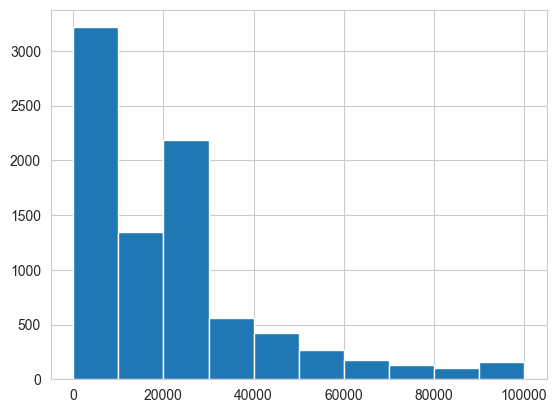

In [108]:
# Plot a histogram for Size as well.
plt.hist(inp1.Size)

{'whiskers': [<matplotlib.lines.Line2D at 0x115b83500>,
 'caps': [<matplotlib.lines.Line2D at 0x115b82330>,
 'boxes': [<matplotlib.lines.Line2D at 0x115b49370>],
 'medians': [<matplotlib.lines.Line2D at 0x115b81460>],
 'fliers': [<matplotlib.lines.Line2D at 0x115b80350>],
 'means': []}

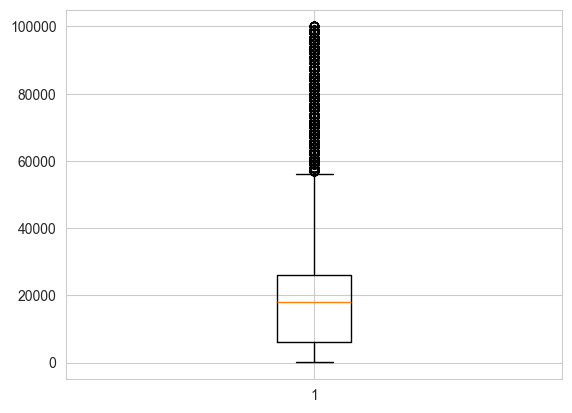

In [109]:
# Question - Create a boxplot for the Size column and report back the median value
plt.boxplot(inp1.Size)

In [110]:
print(np.median(inp1.Size))

18000.0


In [111]:
?plt.bar

### Session 2 - Data Visualisation with Seaborn

Seaborn is Python library to create statistical graphs easily. It is built on top of matplotlib and closely integrated with pandas.

_Functionalities of Seaborn_ :

- Dataset oriented API
- Analysing univariate and bivariate distributions
- Automatic estimation and plotting of  linear regression models
- Convenient views for complex datasets
- Concise control over style
- Colour palettes


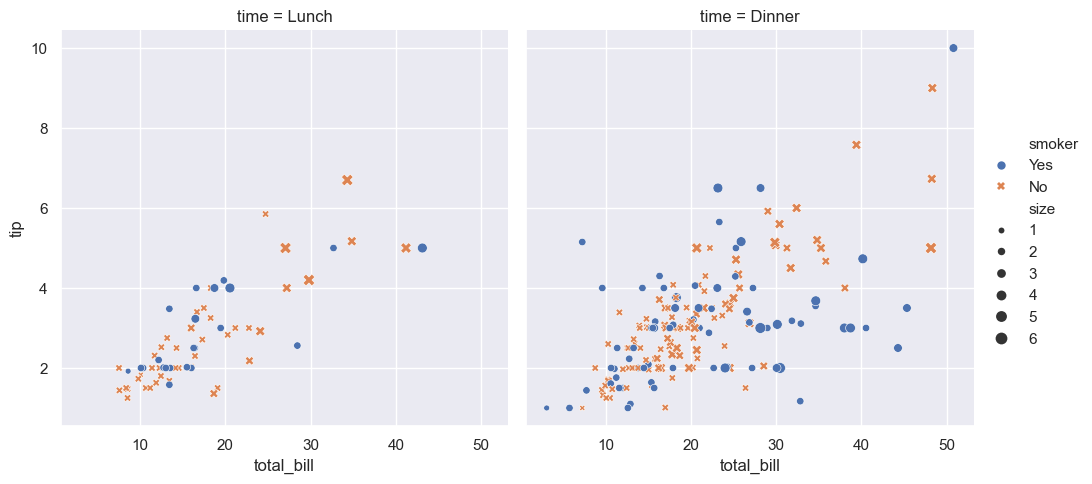

In [112]:
# import the necessary libraries
sns.set_theme()

# Load an example dataset
tips = sns.load_dataset("tips")

# Create a visualization
sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",
    hue="smoker",
    style="smoker",
    size="size",
)

#### Distribution Plots

A distribution plot is pretty similar to the histogram functionality in matplotlib. Instead of a frequency plot, it plots an approximate probability density for that rating bucket. And the curve (or the __KDE__) that gets drawn over the distribution is the approximate probability density curve.

The following is an example of a distribution plot. Notice that now instead of frequency on the left axis, it has the density for each bin or bucket.

![Distplot](images/Distplot.png)

In [113]:
import warnings

warnings.filterwarnings("ignore")

You'll be using sns.distplot for plotting a distribution plot. Check out its official documentation: https://seaborn.pydata.org/generated/seaborn.distplot.html

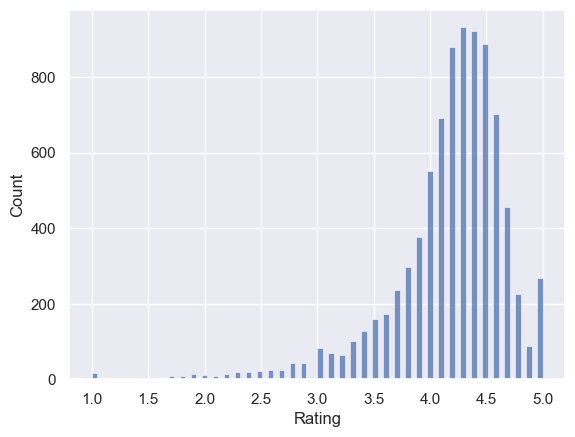

In [114]:
# Create a distribution plot for rating
sns.histplot(inp1["Rating"], kde=False)
plt.show()

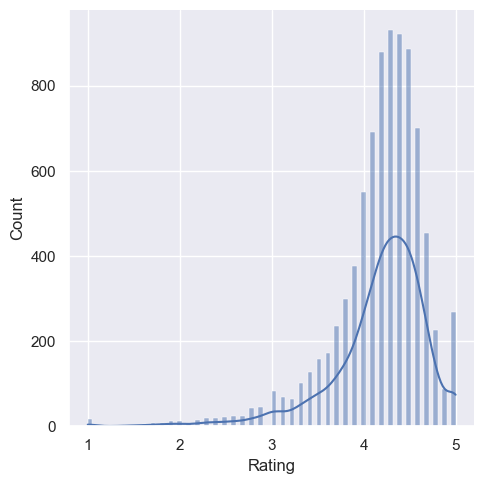

In [115]:
grid = sns.displot(inp1.Rating, kde=True)
grid.tight_layout()
plt.show()

<Axes: ylabel='Rating'>

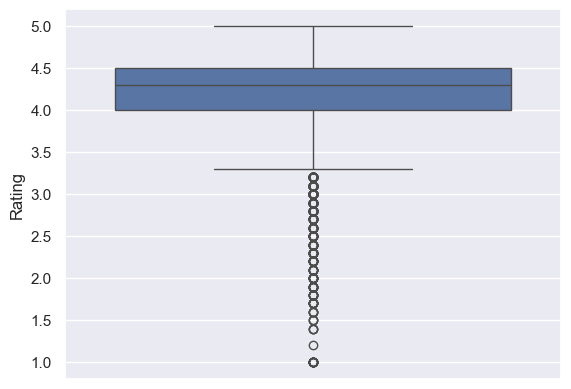

In [116]:
inp1["Rating"].describe()
sns.boxplot(inp1.Rating)

<Axes: xlabel='Rating'>

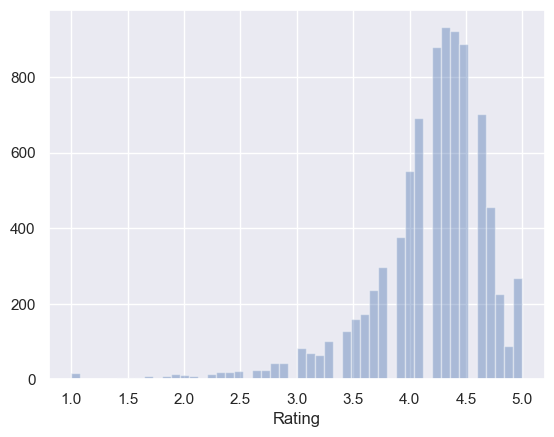

In [117]:
sns.distplot(inp1["Rating"], kde=False)

<Axes: xlabel='Density', ylabel='Rating'>

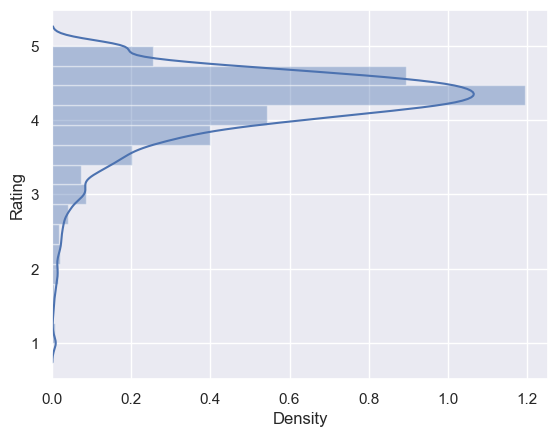

In [118]:
sns.distplot(inp1["Rating"], bins=15, vertical=True)

<Axes: xlabel='Rating', ylabel='Density'>

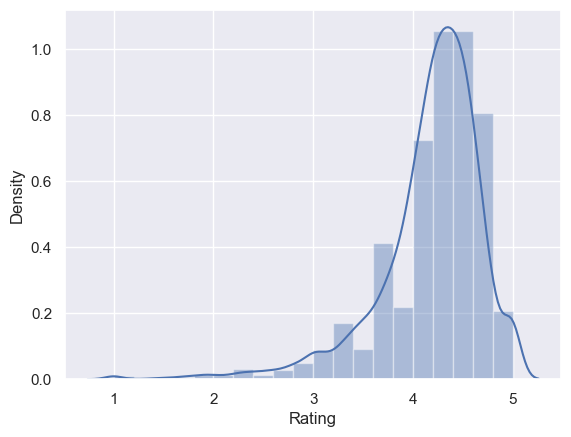

In [119]:
sns.distplot(inp1["Rating"], bins=20)

The difference arises due to the fact that instead of calculating the ‘frequency’, the distplot in Seaborn directly computes the probability density for that rating bucket. And the curve (or the KDE as noted in the documentation for Seaborn) that gets drawn over the distribution is the approximate probability density curve.*

Coming back to the visualisation, the bars that get plotted in both the cases are proportional. For example, the maximum frequency occurs around the 4-4.5 bucket in the histogram plotted by matplotlib. Similarly, the maximum density also lies in the 4-4.5 bucket in the distplot.

The advantage of the distplot view is that it adds a layer of probability distribution without any additional inputs and preserves the same inter-bin relationship as in the Matplotlib version. This statistical view of things is also far more informative and aesthetic than the earlier one.


In [120]:
# Change the number of bins

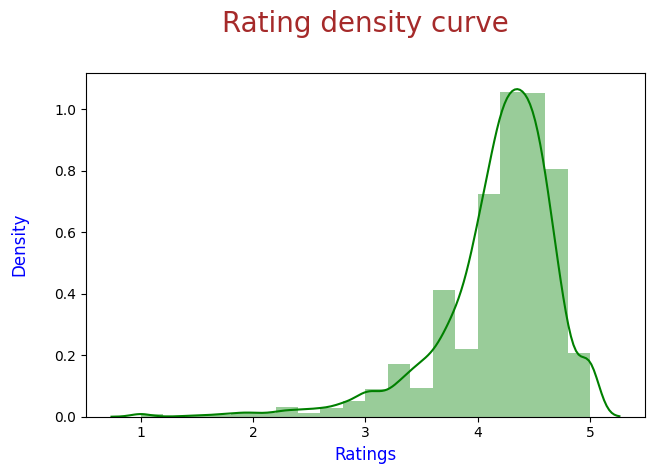

In [121]:
# Change the colour of bins to green
sns.reset_defaults()
sns.distplot(inp1["Rating"], bins=20, color="green")
plt.title("Rating density curve\n", fontsize=20, fontweight=5, color="brown")
plt.tight_layout()
plt.xlabel("Ratings", fontsize=12, fontweight=5, color="blue")
plt.ylabel("Density\n", fontsize=12, fontweight=5, color="blue")
plt.show()

In [122]:
# Apply matplotlib functionalities
help(sns.set_style)

Help on function set_style in module seaborn.rcmod:

set_style(style=None, rc=None)
    Set the parameters that control the general style of the plots.

    The style parameters control properties like the color of the background and
    whether a grid is enabled by default. This is accomplished using the
    matplotlib rcParams system.

    The options are illustrated in the
    :doc:`aesthetics tutorial <../tutorial/aesthetics>`.

    See :func:`axes_style` to get the parameter values.

    Parameters
    ----------
    style : dict, or one of {darkgrid, whitegrid, dark, white, ticks}
        A dictionary of parameters or the name of a preconfigured style.
    rc : dict, optional
        Parameter mappings to override the values in the preset seaborn
        style dictionaries. This only updates parameters that are
        considered part of the style definition.

    Examples
    --------

    .. include:: ../docstrings/set_style.rst



#### Styling Options

One of the biggest advantages of using Seaborn is that you can retain its aesthetic properties and also the Matplotlib functionalities to perform additional customisations. Before we continue with our case study analysis, let’s study some styling options that are available in Seaborn.

-  Check out the official documentation:https://seaborn.pydata.org/generated/seaborn.set_style.html

In [123]:
# Check all the styling options
?sns.set_style

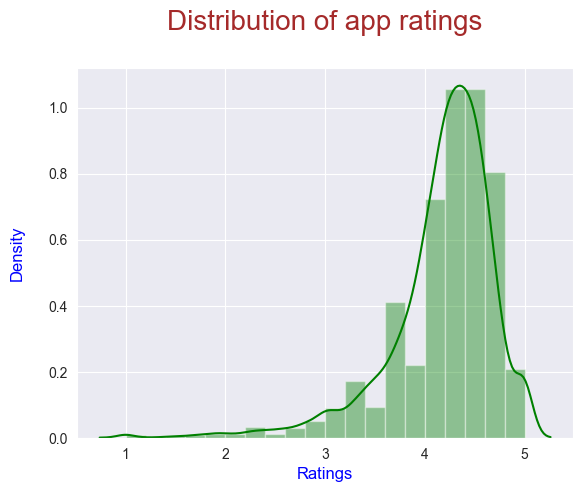

In [124]:
# Change the number of bins to 20
sns.set_style("darkgrid")
sns.distplot(inp1["Rating"], bins=20, color="green")
plt.title("Distribution of app ratings\n", fontsize=20, fontweight=5, color="brown")
plt.xlabel("Ratings", fontsize=12, fontweight=5, color="blue")
plt.ylabel("Density\n", fontsize=12, fontweight=5, color="blue")
plt.show()

In [125]:
x = plt.style.available
len(plt.style.available)
print("ggplot" in x)
print("\t".join(x))

True
Solarize_Light2	_classic_test_patch	_mpl-gallery	_mpl-gallery-nogrid	bmh	classic	dark_background	fast	fivethirtyeight	ggplot	grayscale	petroff10	seaborn-v0_8	seaborn-v0_8-bright	seaborn-v0_8-colorblind	seaborn-v0_8-dark	seaborn-v0_8-dark-palette	seaborn-v0_8-darkgrid	seaborn-v0_8-deep	seaborn-v0_8-muted	seaborn-v0_8-notebook	seaborn-v0_8-paper	seaborn-v0_8-pastel	seaborn-v0_8-poster	seaborn-v0_8-talk	seaborn-v0_8-ticks	seaborn-v0_8-white	seaborn-v0_8-whitegrid	tableau-colorblind10


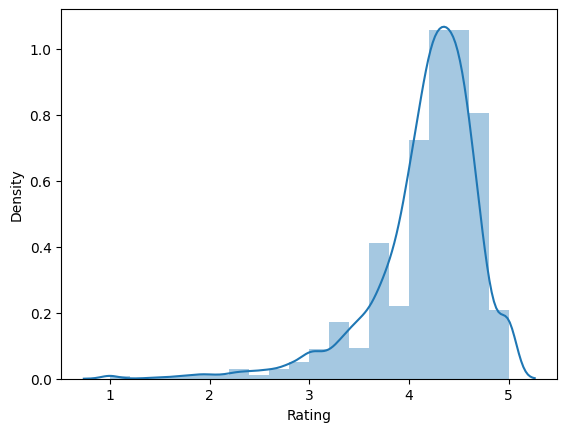

In [126]:
plt.style.use("tableau-colorblind10")
sns.reset_defaults()
sns.distplot(inp1["Rating"], bins=20)
plt.show()

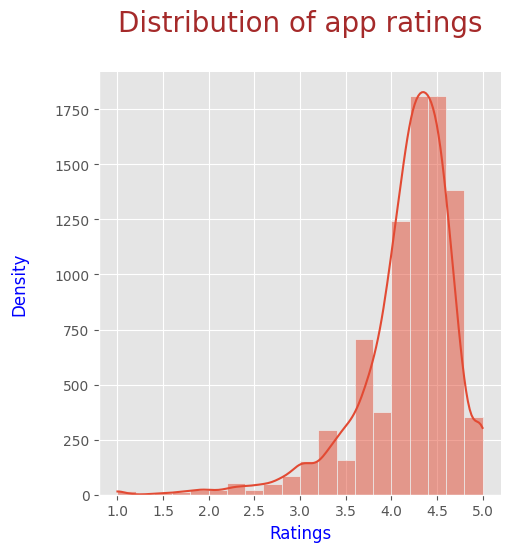

In [127]:
plt.style.use("ggplot")
sns.displot(inp1["Rating"], bins=20, kde=True)
plt.title("Distribution of app ratings\n", fontsize=20, fontweight=5, color="brown")
plt.xlabel("Ratings", fontsize=12, fontweight=5, color="blue")
plt.ylabel("Density\n", fontsize=12, fontweight=5, color="blue")
plt.show()

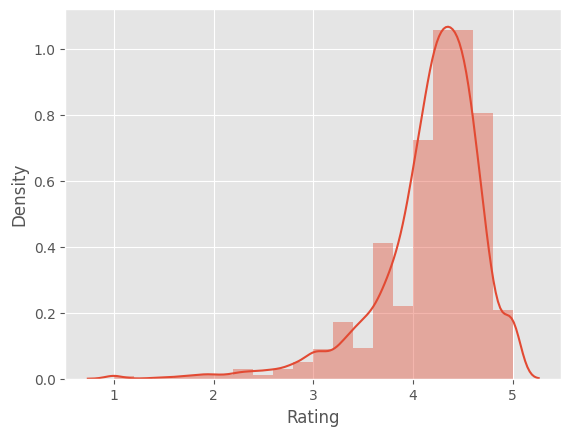

In [128]:
sns.distplot(inp1["Rating"], bins=20)
plt.show()

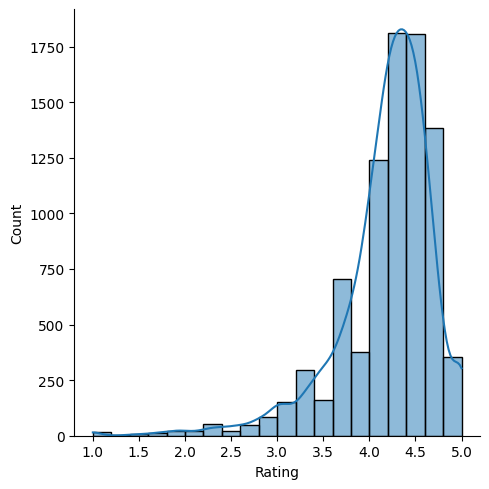

In [129]:
plt.style.use("default")
sns.displot(inp1["Rating"], bins=20, kde=True)
plt.show()

#### Pie-Chart and Bar Chart

For analysing how a numeric variable changes across several categories of a categorical variable you utilise either a pie chart or a box plot

For example, if you want to visualise the responses of a marketing campaign, you can use the following views:

![PieChart](images/pie.png)

![barChart](images/bar.png)

- You'll be using the pandas method of plotting both a pie chart and a bar chart. Check out their official documentations:
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
   - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.pie.html

In [130]:
# Analyse the Content Rating column
inp1["Content Rating"].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [131]:
# Remove the rows with values which are less represented
inp1["Content Rating"].value_counts()

Content Rating
Everyone           6898
Teen                918
Mature 17+          417
Everyone 10+        336
Adults only 18+       3
Unrated               1
Name: count, dtype: int64

In [132]:
inp1[
    ~(
        (inp1["Content Rating"] == "Unrated")
        | (inp1["Content Rating"] == "Adults only 18+")
    )
].shape

(8569, 13)

In [133]:
inp1.shape

(8573, 13)

In [134]:
inp1 = inp1[
    ~(
        (inp1["Content Rating"] == "Unrated")
        | (inp1["Content Rating"] == "Adults only 18+")
    )
]

In [135]:
# Reset the index
inp1.reset_index()

,index,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.000000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.000000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.000000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.000000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8564,10834,FR Calculator,FAMILY,4.0,7,2600.000000,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
8565,10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.000000,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
8566,10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.000000,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
8567,10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,21516.529524,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [136]:
# Check the apps belonging to different categories of Content Rating
inp2 = inp1.set_index("Content Rating")

In [137]:
inp2

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Genres,Last Updated,Current Ver,Android Ver
Content Rating,,,,,,,,,,,,
Everyone,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.000000,10000,Free,0.0,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
Everyone,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.000000,500000,Free,0.0,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
Everyone,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.000000,5000000,Free,0.0,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
Teen,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.000000,50000000,Free,0.0,Art & Design,"June 8, 2018",Varies with device,4.2 and up
Everyone,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.000000,100000,Free,0.0,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...
Everyone,FR Calculator,FAMILY,4.0,7,2600.000000,500,Free,0.0,Education,"June 18, 2017",1.0.0,4.1 and up
Everyone,Sya9a Maroc - FR,FAMILY,4.5,38,53000.000000,5000,Free,0.0,Education,"July 25, 2017",1.48,4.1 and up
Everyone,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.000000,100,Free,0.0,Education,"July 6, 2018",1.0,4.1 and up


In [138]:
frame = inp2.groupby("Category")

In [139]:
# inp2[inp2["Category"]]

In [140]:
inp1 = inp1[~inp1["Content Rating"].isin(["Unrated", "Adults only 18+"])]

In [141]:
inp1.shape

(8569, 13)

In [142]:
inp1.reset_index(drop=True, inplace=True)

In [143]:
inp1

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.000000,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.000000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.000000,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.000000,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.000000,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8564,FR Calculator,FAMILY,4.0,7,2600.000000,500,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
8565,Sya9a Maroc - FR,FAMILY,4.5,38,53000.000000,5000,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
8566,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.000000,100,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
8567,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,21516.529524,1000,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [144]:
inp1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8569 entries, 0 to 8568
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8569 non-null   object 
 1   Category        8569 non-null   object 
 2   Rating          8569 non-null   float64
 3   Reviews         8569 non-null   int32  
 4   Size            8569 non-null   float64
 5   Installs        8569 non-null   int64  
 6   Type            8569 non-null   object 
 7   Price           8569 non-null   float64
 8   Content Rating  8569 non-null   object 
 9   Genres          8569 non-null   object 
 10  Last Updated    8569 non-null   object 
 11  Current Ver     8569 non-null   object 
 12  Android Ver     8569 non-null   object 
dtypes: float64(3), int32(1), int64(1), object(8)
memory usage: 836.9+ KB


In [145]:
inp1["Content Rating"].value_counts()

Content Rating
Everyone        6898
Teen             918
Mature 17+       417
Everyone 10+     336
Name: count, dtype: int64

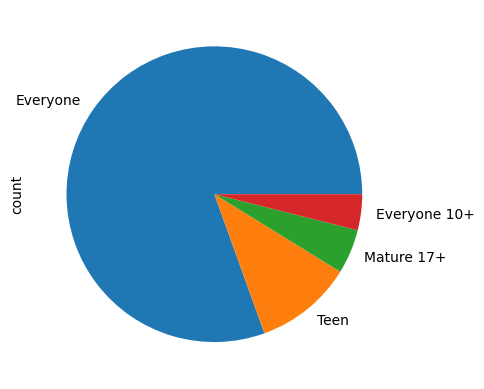

In [146]:
# Plot a pie chart
inp1["Content Rating"].value_counts().plot.pie()
plt.show()

In [147]:
# Plot a bar chart
# plt.bar(inp1["Content Rating"].value_counts(), inp1["Reviews"])
# plt.show()

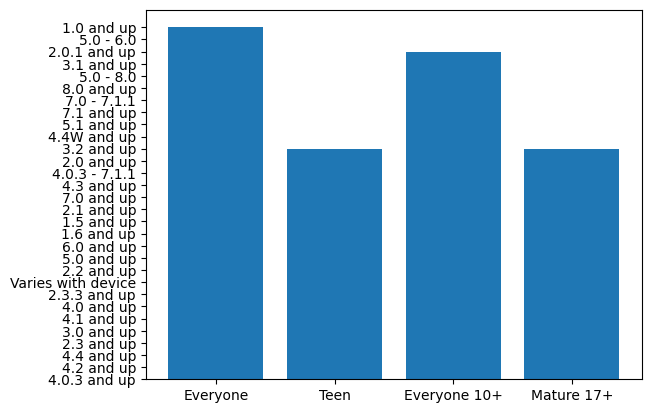

In [148]:
plt.bar(inp1["Content Rating"], inp1["Android Ver"])
plt.show()

In [149]:
# Question - Plot a bar plot for checking the 4th highest Android version type
plt.bar(inp1["Content Rating"], inp1["Android Ver"])

<BarContainer object of 8569 artists>

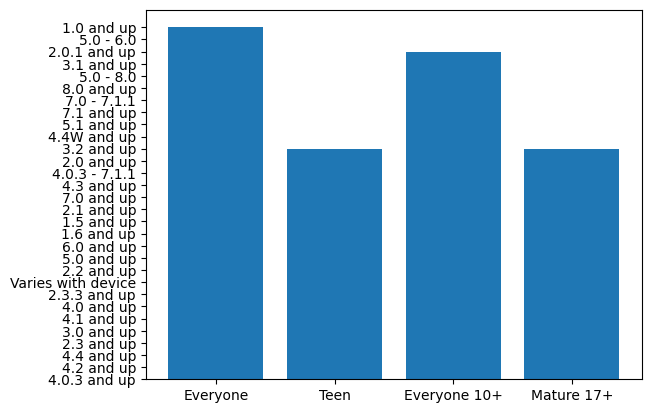

In [150]:
plt.show()

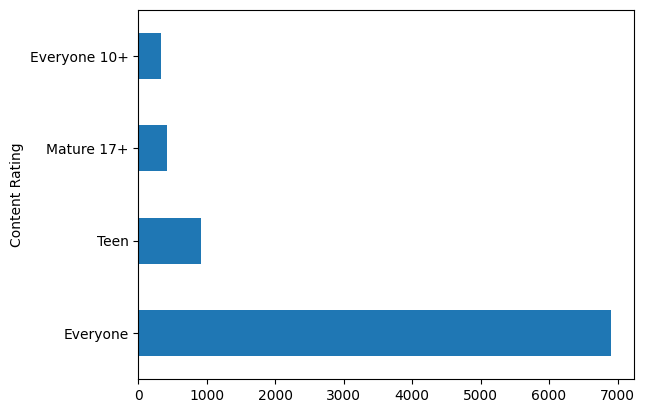

In [151]:
inp1["Content Rating"].value_counts().plot.barh()
plt.show()

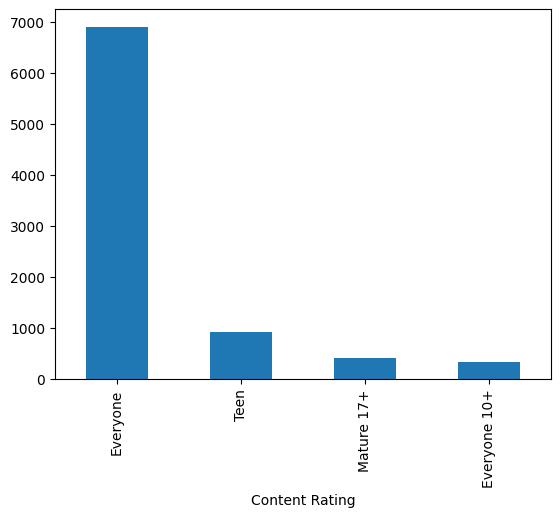

In [152]:
inp1["Content Rating"].value_counts().plot.bar()
plt.show()

In [153]:
inp1["Android Ver"].value_counts().plot.bar()

<Axes: xlabel='Android Ver'>

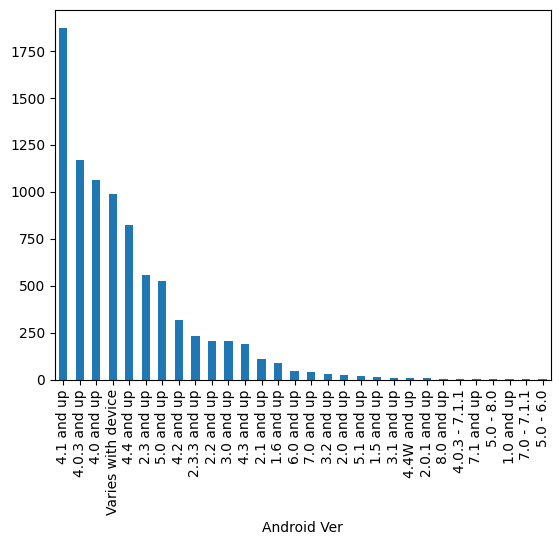

In [154]:
plt.show()

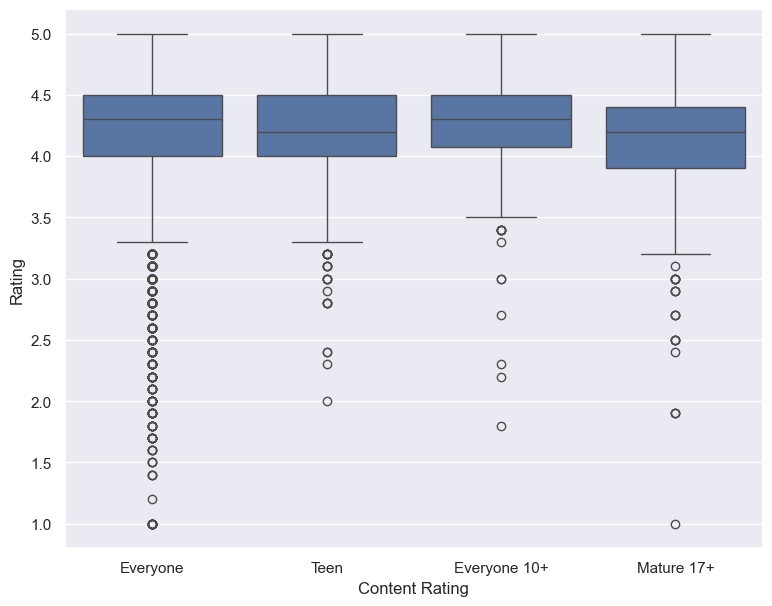

In [209]:
sns.set_theme(color_codes=True)
plt.figure(figsize=(9, 7))
sns.boxplot(data=inp1, x="Content Rating", y="Rating")
plt.show()

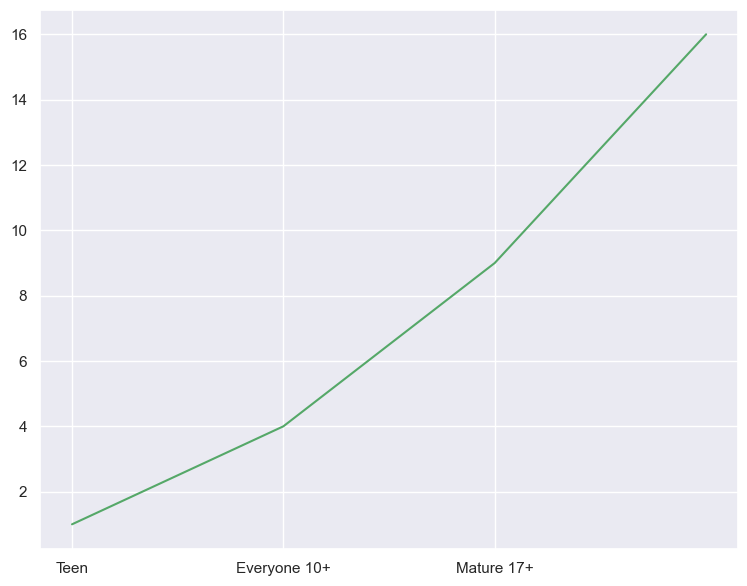

In [208]:
sns.set_theme(color_codes=True)
# Create a plot
plt.plot(
    [1, 2, 3, 4], [1, 4, 9, 16], "g"
)  # 'b' now refers to the blue color from the Seaborn palette

plt.show()

In [155]:
plt.scatter(inp1["Reviews"], inp1["Installs"])

In [156]:
sns.scatterplot([inp1["Reviews"], inp1["Installs"]])

<Axes: >

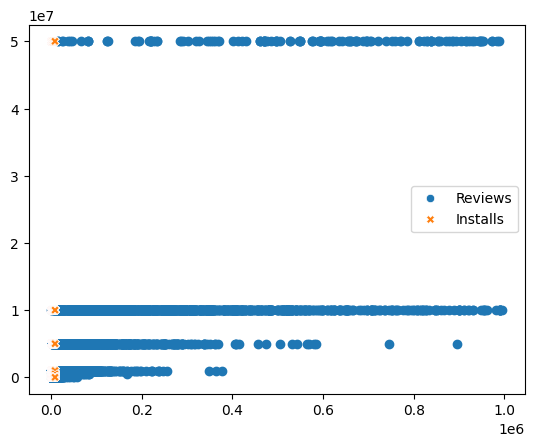

In [157]:
plt.show()

#### Scatter Plots

Scatterplots are perhaps one of the most commonly used as well one of the most powerful visualisations you can use in the field of machine learning. They are pretty crucial in revealing relationships between the data points and you can generally deduce some sort of trends in the data with the help of a scatter plot.

![Scatterplot](images/scatter.png)

- They're pretty useful in regression problems to check whether a linear trend exists in the data or not. For example, in the image below, creating a linear model in the first case makes far more sense since a clear straight line trend is visible.

![Scatterplot-Reg](images/regression3.png)

- Also, they help in observing __naturally occuring clusters__. In the following image, the marks of students in Maths and Biology has been plotted.You can clearly group the students to 4 clusters now. Cluster 1 are students who score very well in Biology but very poorly in Maths, Cluster 2 are students who score equally well in both the subjects and so on.

![Scatter-Clusters](images/Clusters.png)

**Note**: You'll be studying about both Regression and Clustering in greater detail in the machine learning modules

You'll be using **sns.jointplot()** for creating a scatter plot. Check out its documentation:
https://seaborn.pydata.org/generated/seaborn.jointplot.html

In [158]:
penguins = sns.load_dataset("penguins")
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [159]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [160]:
sns.jointplot(penguins, x="bill_depth_mm", y="bill_length_mm")

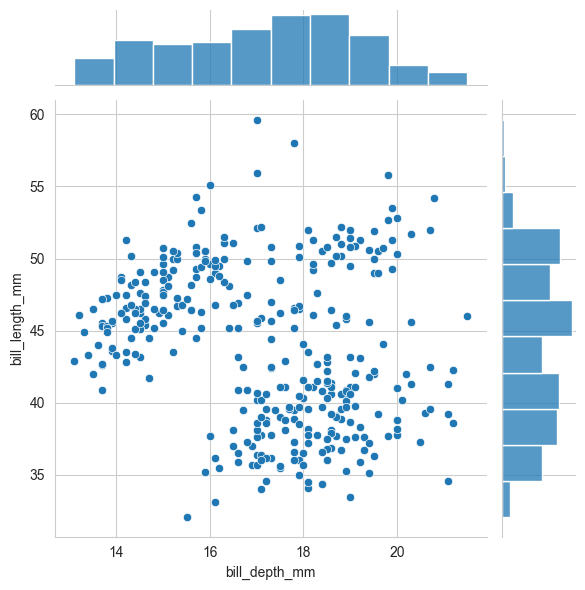

In [161]:
plt.show()

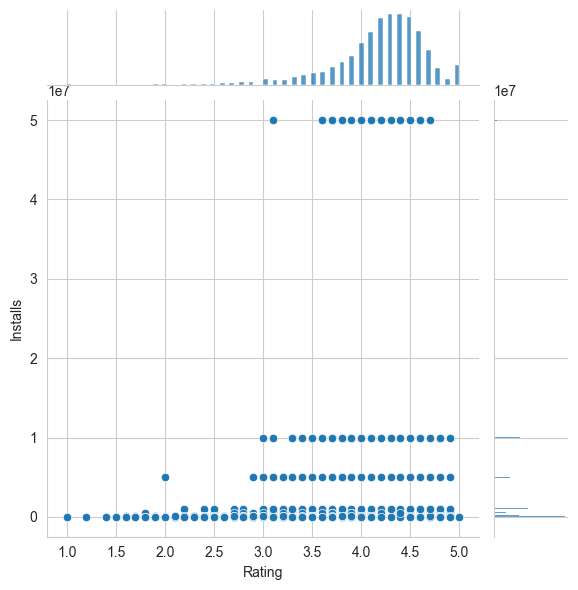

In [162]:
reviews = inp1["Reviews"] * (10**4)
sns.jointplot(inp1, x="Rating", y="Installs")
plt.show()

In [163]:
inp1["Reviews"][0]

np.int32(159)

### Scatter plot between size of the App and Rating... Anything
**Guessing no,let's see**


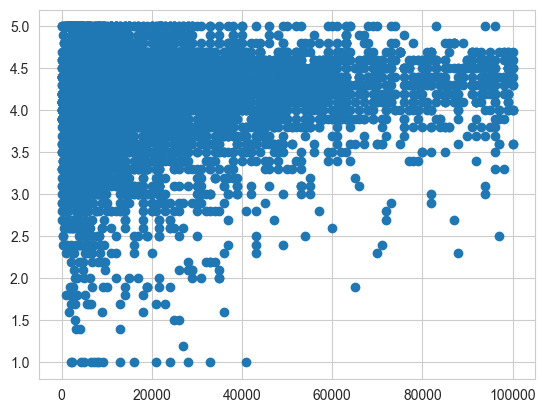

In [164]:
plt.scatter(inp1["Size"], inp1["Rating"])
plt.show()

In [165]:
# inp1.to_csv("Play_Store_cleaned.csv")

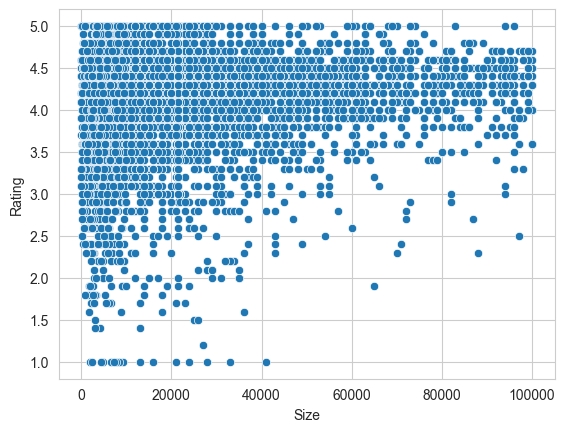

In [166]:
sns.scatterplot(inp1, x="Size", y="Rating")

plt.show()

In [167]:
###Size vs Rating

##Plot a scatter-plot in the matplotlib way between Size and Rating

In [168]:
### Plot the same thing now using a jointplot

In [169]:
## Plot a jointplot for Price and Rating

**Reg Plots**

- These are an extension to the jointplots, where a regression line is added to the view

In [170]:
##Plot a reg plot for Price and Rating and observe the trend

In [171]:
## Question - Plot a reg plot for Price and Rating again for only the paid apps.

**Pair Plots**

 - When you have several numeric variables, making multiple scatter plots becomes rather tedious. Therefore, a pair plot visualisation is preferred where all the scatter plots are in a single view in the form of a matrix
 - For the non-diagonal views, it plots a **scatter plot** between 2 numeric variables
 - For the diagonal views, it plots a **histogram**

Pair Plots help in identifying the trends between a target variable and the predictor variables pretty quickly. For example, say you want to predict how your company’s profits are affected by three different factors. In order to choose which you created a pair plot containing profits and the three different factors as the variables. Here are the scatterplots of profits vs the three variables that you obtained from the pair plot.

![Pairplots](images/pairplots2.png)

It is clearly visible that the left-most factor is the most prominently related to the profits, given how linearly scattered the points are and how randomly scattered the rest two factors are.

You'll be using **sns.pairplot()** for this visualisation. Check out its official documentation:https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [172]:
## Create a pair plot for Reviews, Size, Price and Rating

**Bar Charts Revisited**

- Here, you'll be using bar charts once again, this time using the **sns.barplot()** function. Check out its official documentation:https://seaborn.pydata.org/generated/seaborn.barplot.html
- You can modify the **estimator** parameter to change the aggregation value of your barplot

In [173]:
##Plot a bar plot of Content Rating vs Average Rating

In [174]:
##Plot the bar plot again with Median Rating

In [175]:
##Plot the above bar plot using the estimator parameter

In [176]:
##Plot the bar plot with only the 5th percentile of Ratings

In [177]:
##Question - Plot the bar plot with the minimum Rating

__Box Plots Revisited__

- Apart from outlier analysis, box plots are great at comparing the spread and analysing a numerical variable across several categories
- Here you'll be using **sns.boxplot()** function to plot the visualisation. Check out its documentation: https://seaborn.pydata.org/generated/seaborn.boxplot.html




In [178]:
##Plot a box plot of Rating vs Content Rating

In [179]:
##Question - Plot a box plot for the Rating column only

In [180]:
##Question - Plot a box plot of Ratings across the 4 most popular Genres

#### Heat Maps

Heat mapsutilise the concept of using colours and colour intensities to visualise a range of values. You must have seen heat maps in cricket or football broadcasts on television to denote the players’ areas of strength and weakness.

![HeatMap](images/heatmap1.png)

- In python, you can create a heat map whenever you have a rectangular grid or table of numbers analysing any two features

![heatmap2](images/heatmap2.png)

- You'll be using **sns.heatmap()** to plot the visualisation. Checkout its official documentation :https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [181]:
##Ratings vs Size vs Content Rating

##Prepare buckets for the Size column using pd.qcut

In [182]:
##Create a pivot table for Size_buckets and Content Rating with values set to Rating

In [183]:
##Change the aggregation to median

In [184]:
##Change the aggregation to 20th percentile

In [185]:
##Store the pivot table in a separate variable

In [186]:
##Plot a heat map

In [187]:
##Apply customisations

In [188]:
##Question - Replace Content Rating with Review_buckets in the above heat map
##Keep the aggregation at minimum value for Rating

### Session 3: Additional Visualisations

#### Line Plots

- A line plot tries to observe trends using time dependent data.
-  For this part, you'll be using **pd.to_datetime()** function. Check out its documentation:https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html


In [189]:
## Extract the month from the Last Updated Date

In [190]:
## Find the average Rating across all the months

In [191]:
## Plot a line graph

#### Stacked Bar Charts

- A stacked bar chart breaks down each bar of the bar chart on the basis of a different category
- For example, for the Campaign Response bar chart you saw earlier, the stacked bar chart is also showing the Gender bifurcation as well

![Stacked](images\stacked.png)

In [192]:
## Create a pivot table for Content Rating and updated Month with the values set to Installs

In [193]:
##Store the table in a separate variable

In [194]:
##Plot the stacked bar chart.

In [195]:
##Plot the stacked bar chart again wrt to the proportions.

#### Plotly

Plotly is a Python library used for creating interactive visual charts. You can take a look at how you can use it to create aesthetic looking plots with a lot of user-friendly functionalities like hover, zoom, etc.

Check out this link for installation and documentation:https://plot.ly/python/getting-started/

In [196]:
# Install plotly

In [197]:
# Take the table you want to plot in a separate variable

In [198]:
# Import the plotly libraries

In [199]:
# Prepare the plot